# Segmentez les clients d'un site e-commerce

## Contexte de l'étude
Vous êtes consultant pour Olist, une entreprise brésilienne qui propose une solution de vente sur les marketplaces en ligne.

Votre objectif est de comprendre les différents types d’utilisateurs grâce à leur comportement et à leurs données personnelles.

Vous devrez fournir à l’équipe marketing une description actionable de votre segmentation et de sa logique sous-jacente pour une utilisation optimale, ainsi qu’une proposition de contrat de maintenance basée sur une analyse de la stabilité des segments au cours du temps.

## Contexte du notebook  
On effectue ici une analyse exploratoire plus détaillée à partir de la table RFM réalisée précédemment et ainsi réaliser une segmentation clientèle par un algorithme non supervisé choisi après plusieurs essais.

## Sommaire

- Importation des données
- Analyse exploratoire
    - Histogrammes
- Preprocessing
- Clustering par k-means
    - Calcul du nombre idéal de clusters  
    - Analyse par composantes principales
    - Réduction du dataset
        - Inerties intraclasses
        - Davies- score et SilhouetteVisualizer
        - SilhouetteVisualizer
        - ACP
        - Projection des individus sur les axes de l'ACP
        - Cartographies des individus par moyenne des clusters
        - Diagrammes boîte à moustaches
    
    
# Importation des données

In [1]:
# Importation générale
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import joblib

In [2]:
# Importation des librairies pour la prédiction

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
from sklearn import decomposition
# from sklearn import preprocessing
from sklearn.cluster import KMeans


from sklearn.pipeline import Pipeline
from sklearn import linear_model
from sklearn.kernel_ridge import KernelRidge
from sklearn.svm import SVR
from sklearn import tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor


# Visualisation des diagrammes
from sklearn import set_config


In [3]:
# Permet d'élargir le notebook
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:70% !important; }</style>"))

In [4]:
## Import des données brutes et analyse de leur architecture

path_p4_local = r'D:\Utilisateurs\Damien\Documents\Test_code\test_python\OCR_projets\IML\P4_'
# path_p4_cloud = 

data_rfm = pd.read_csv(path_p4_local + r'\data_clean.csv',sep="\t",low_memory=False)

In [5]:
data_rfm

,customer_unique_id,monetary,frequency,recency_days,mean_payment_installments,mean_review,mean_volume_cm3,mean_weight_g,mean_product_name_lenght,mean_product_description_lenght,mean_product_photos_qty,mean_delay_days
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90,1,1548,8.0,5.0,7616.0,1500.0,60.0,236.0,1.0,6.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,1,1551,1.0,4.0,5148.0,375.0,56.0,635.0,1.0,3.0
2,0000f46a3911fa3c0805444483337064,86.22,1,1973,8.0,3.0,43750.0,1500.0,49.0,177.0,3.0,25.0
3,0000f6ccb0745a6a4b88665a16c9f078,43.62,1,1757,4.0,4.0,1045.0,150.0,43.0,1741.0,5.0,20.0
4,0004aac84e0df4da2b147fca70cf8255,196.89,1,1724,6.0,5.0,528.0,6050.0,58.0,794.0,3.0,13.0
...,...,...,...,...,...,...,...,...,...,...,...,...
91473,fffcf5a5ff07b0908bd4e2dbc735a684,4134.84,2,1883,10.0,5.0,251625.0,30000.0,54.0,478.5,1.0,27.0
91474,fffea47cd6d3cc0a88bd621562a9d061,84.58,1,1698,1.0,4.0,32076.0,1720.0,37.0,506.0,2.0,30.0
91475,ffff371b4d645b6ecea244b27531430a,112.46,1,2005,1.0,5.0,3315.0,600.0,57.0,716.0,5.0,14.0
91476,ffff5962728ec6157033ef9805bacc48,133.69,1,1556,5.0,5.0,4480.0,444.0,35.0,591.0,3.0,11.0


# Analyse exploratoire  
## Histogrammes

In [6]:
data_rfm_client = data_rfm.set_index("customer_unique_id")
data_rfm_client

,monetary,frequency,recency_days,mean_payment_installments,mean_review,mean_volume_cm3,mean_weight_g,mean_product_name_lenght,mean_product_description_lenght,mean_product_photos_qty,mean_delay_days
customer_unique_id,,,,,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,141.90,1,1548,8.0,5.0,7616.0,1500.0,60.0,236.0,1.0,6.0
0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,1,1551,1.0,4.0,5148.0,375.0,56.0,635.0,1.0,3.0
0000f46a3911fa3c0805444483337064,86.22,1,1973,8.0,3.0,43750.0,1500.0,49.0,177.0,3.0,25.0
0000f6ccb0745a6a4b88665a16c9f078,43.62,1,1757,4.0,4.0,1045.0,150.0,43.0,1741.0,5.0,20.0
0004aac84e0df4da2b147fca70cf8255,196.89,1,1724,6.0,5.0,528.0,6050.0,58.0,794.0,3.0,13.0
...,...,...,...,...,...,...,...,...,...,...,...
fffcf5a5ff07b0908bd4e2dbc735a684,4134.84,2,1883,10.0,5.0,251625.0,30000.0,54.0,478.5,1.0,27.0
fffea47cd6d3cc0a88bd621562a9d061,84.58,1,1698,1.0,4.0,32076.0,1720.0,37.0,506.0,2.0,30.0
ffff371b4d645b6ecea244b27531430a,112.46,1,2005,1.0,5.0,3315.0,600.0,57.0,716.0,5.0,14.0


In [7]:
np.log(data_rfm_client+1)

,monetary,frequency,recency_days,mean_payment_installments,mean_review,mean_volume_cm3,mean_weight_g,mean_product_name_lenght,mean_product_description_lenght,mean_product_photos_qty,mean_delay_days
customer_unique_id,,,,,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,4.962145,0.693147,7.345365,2.197225,1.791759,8.938138,7.313887,4.110874,5.468060,0.693147,1.945910
0000b849f77a49e4a4ce2b2a4ca5be3f,3.338967,0.693147,7.347300,0.693147,1.609438,8.546558,5.929589,4.043051,6.455199,0.693147,1.386294
0000f46a3911fa3c0805444483337064,4.468434,0.693147,7.587817,2.197225,1.386294,10.686270,7.313887,3.912023,5.181784,1.386294,3.258097
0000f6ccb0745a6a4b88665a16c9f078,3.798182,0.693147,7.471932,1.609438,1.609438,6.952729,5.017280,3.784190,7.462789,1.791759,3.044522
0004aac84e0df4da2b147fca70cf8255,5.287711,0.693147,7.452982,1.945910,1.791759,6.270988,8.707979,4.077537,6.678342,1.386294,2.639057
...,...,...,...,...,...,...,...,...,...,...,...
fffcf5a5ff07b0908bd4e2dbc735a684,8.327446,1.098612,7.541152,2.397895,1.791759,12.435699,10.308986,4.007333,6.172744,0.693147,3.332205
fffea47cd6d3cc0a88bd621562a9d061,4.449452,0.693147,7.437795,0.693147,1.609438,10.375895,7.450661,3.637586,6.228511,1.098612,3.433987
ffff371b4d645b6ecea244b27531430a,4.731450,0.693147,7.603898,0.693147,1.791759,8.106515,6.398595,4.060443,6.575076,1.791759,2.708050


In [8]:
# data_rfm_client.drop(['mean_volume','mean_weight_g','mean_product_name_lenght','mean_product_description_lenght'],axis=1,inplace=True)
# data_rfm_client

In [9]:
# data_rfm_client.drop(['mean_product_photos_qty'],axis=1,inplace=True)
# data_rfm_client

In [10]:
# data_rfm_client.drop(['mean_volume','mean_weight_g','mean_product_name_lenght','mean_product_description_lenght','mean_product_photos_qty'],axis=1,inplace=True)
# data_rfm_client

# Preprocessing
On choisit de visualiser les histogrammes après normalisation et standardisation des données pour occulter les effets d'échelles.

In [11]:
# préparation des données pour le clustering

# X_values = data_rfm.set_index("customer_unique_id").values

X_values = data_rfm_client.values
X_scaled = StandardScaler().fit_transform(X_values)

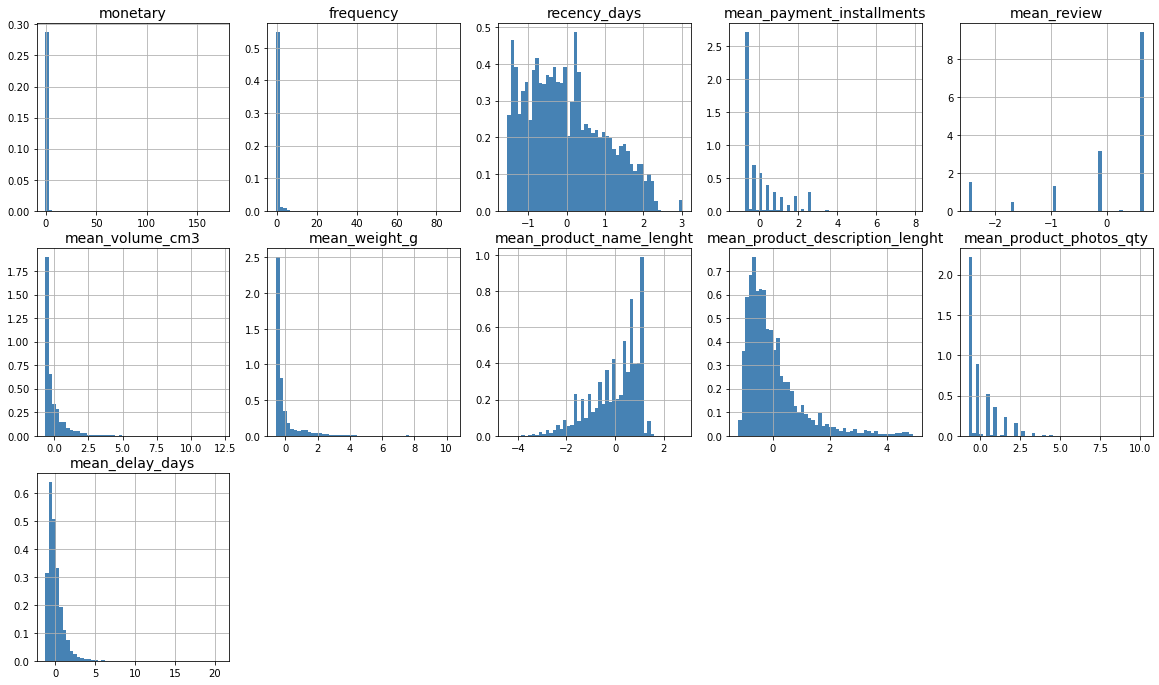

In [12]:
fig = plt.figure(figsize=(20,20))
for feat_idx in range(X_scaled.shape[1]):
    ax = fig.add_subplot(5,5, (feat_idx+1))
    h = ax.hist(X_scaled[:, feat_idx], bins=50, color='steelblue', density=True, edgecolor='none')
    ax.set_title(data_rfm_client.columns[feat_idx], fontsize=14)
    plt.grid()

Pour rendre les données plus gaussiennes, on choisist de réaliser une transformation de type logarithmique:

In [13]:
data_rfm_client.describe()

,monetary,frequency,recency_days,mean_payment_installments,mean_review,mean_volume_cm3,mean_weight_g,mean_product_name_lenght,mean_product_description_lenght,mean_product_photos_qty,mean_delay_days
count,91478.000000,91478.000000,91478.000000,91478.000000,91478.000000,91478.000000,91478.000000,91478.000000,91478.000000,91478.000000,91478.000000
mean,212.306413,1.237543,1673.429152,2.903022,4.154607,15194.698723,2104.600486,48.870792,795.295005,2.256645,12.057805
std,631.266236,0.844336,152.612782,2.679680,1.279291,23126.874559,3729.503289,9.886646,650.013953,1.736869,9.461141
min,9.590000,1.000000,1437.000000,0.000000,1.000000,168.000000,0.000000,5.000000,4.000000,1.000000,0.000000
25%,63.845000,1.000000,1550.000000,1.000000,4.000000,2856.000000,300.000000,43.000000,354.000000,1.000000,6.000000
50%,112.840000,1.000000,1654.000000,2.000000,5.000000,6600.000000,700.000000,52.000000,611.000000,2.000000,10.000000
75%,202.760000,1.000000,1782.000000,4.000000,5.000000,18375.000000,1825.000000,57.000000,998.000000,3.000000,15.000000
max,109312.640000,75.000000,2132.000000,24.000000,5.000000,296208.000000,40425.000000,76.000000,3992.000000,20.000000,208.000000


In [14]:
from sklearn.preprocessing import PowerTransformer
X_trf = PowerTransformer(method="yeo-johnson").fit_transform(data_rfm_client)

C:\Users\daims\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:3253: RuntimeWarning: divide by zero encountered in log
  loglike = -n_samples / 2 * np.log(x_trans.var())


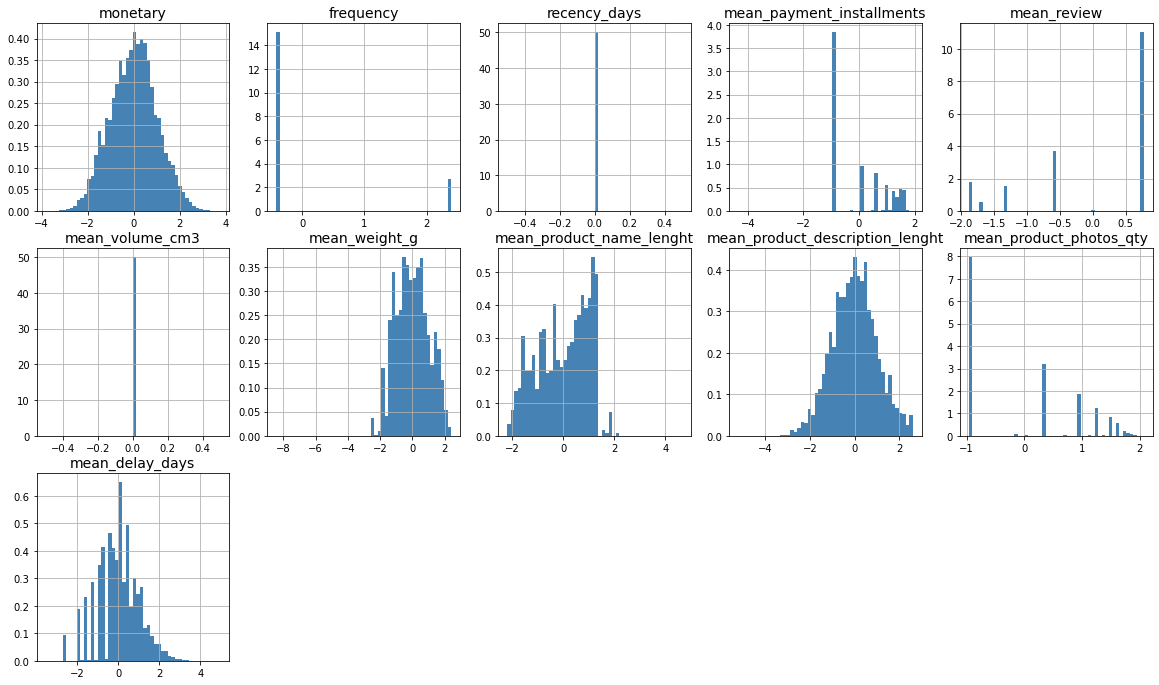

In [15]:
fig = plt.figure(figsize=(20,20))
for feat_idx in range(X_trf.shape[1]):
    ax = fig.add_subplot(5,5, (feat_idx+1))
    h = ax.hist(X_trf[:, feat_idx], bins=50, color='steelblue', density=True, edgecolor='none')
    ax.set_title(data_rfm_client.columns[feat_idx], fontsize=14)
    plt.grid()

Un problème lié à cette transformation nous fait perdre la valeur de certaines données. Après une recherche sur la compréhension de ce problème qui n'a pas été résolu, on choisit d'implémenter de manière brute la transformation.  
Sachant que toute les valeurs de nos variables avant standardisation sont positives, on réalise la transformation comme suit:

In [16]:
# X_log = np.log(1+X_values)
# X_log_scaled =  StandardScaler().fit_transform(X_log)

In [17]:
# Transformation log sur des entrées positives
from sklearn.preprocessing import PowerTransformer
pt_trf = PowerTransformer(method="box-cox")
X_boxcow = pt_trf.fit_transform(1+X_values)
# X_boxcow = PowerTransformer(method="box-cox").fit_transform(1+X_values)

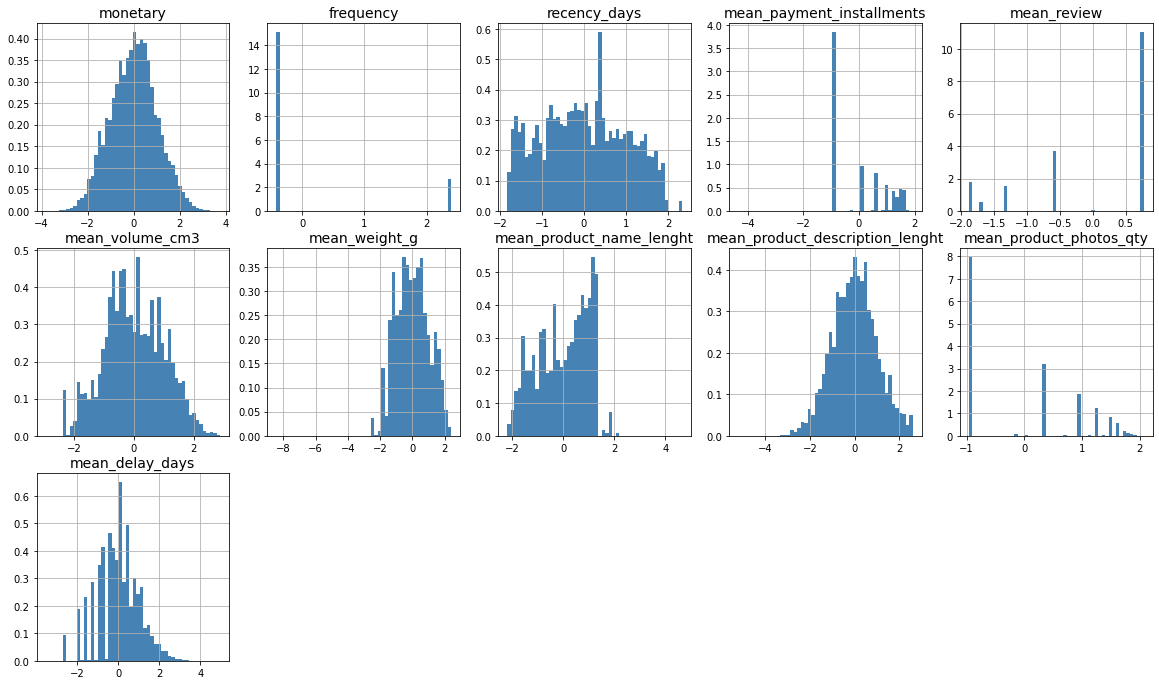

In [18]:
fig = plt.figure(figsize=(20,20))
for feat_idx in range(X_boxcow.shape[1]):
    ax = fig.add_subplot(5,5, (feat_idx+1))
    h = ax.hist(X_boxcow[:, feat_idx], bins=50, color='steelblue', density=True, edgecolor='none')
    ax.set_title(data_rfm_client.columns[feat_idx], fontsize=14)
    plt.grid()

On retrouve bien sur ces graphes les données perdues par l'autre méthode logarithmique.

# Clustering par k-means

## Calcul du nombre idéal de clusters.  

On réalise ici une boucle de calcul qui va effectuer l'algorithme du K-means pour différente valeurs de clusters à initialiser, puis calculer leur inertie interclasse et déterminer avec la règle du coude sur cette inertie laquelle donne un nombre de cluster intéressant et pertinent.

In [19]:
X_trf=X_boxcow

In [20]:
column_data_num = data_rfm_client.describe().columns.to_list()
column_data_num

['monetary',
 'frequency',
 'recency_days',
 'mean_payment_installments',
 'mean_review',
 'mean_volume_cm3',
 'mean_weight_g',
 'mean_product_name_lenght',
 'mean_product_description_lenght',
 'mean_product_photos_qty',
 'mean_delay_days']

In [21]:
# from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import silhouette_score

wcss = []
db_score = []
sil_score = []
nb_clust_max = 10 # len(column_data_num_cut)

for i in range(2, nb_clust_max): # 2 car davies_bouldin_score seulement si nb_cluster >1
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42) 
    kmeans.fit(X_trf) 
    wcss.append(kmeans.inertia_)
    db_score.append(davies_bouldin_score(X_trf, kmeans.labels_))
    sil_score.append(silhouette_score(X_trf, kmeans.labels_))
    print("Calculation done for the following number of clusters: " + str(i))

Calculation done for the following number of clusters: 2
Calculation done for the following number of clusters: 3
Calculation done for the following number of clusters: 4
Calculation done for the following number of clusters: 5
Calculation done for the following number of clusters: 6
Calculation done for the following number of clusters: 7
Calculation done for the following number of clusters: 8
Calculation done for the following number of clusters: 9


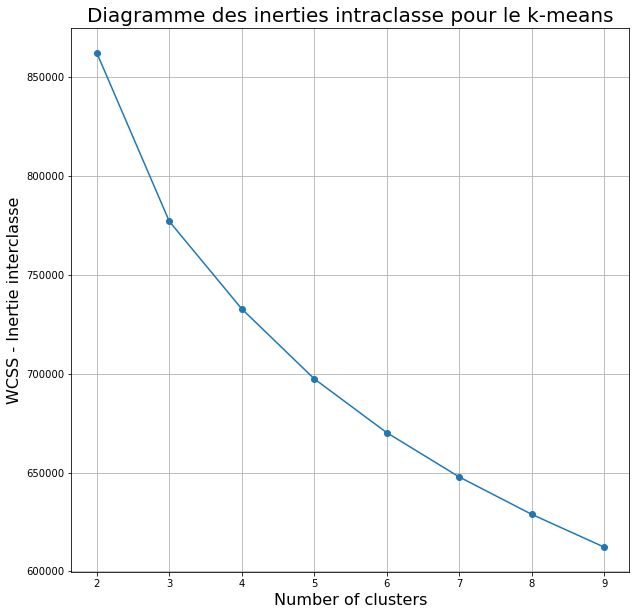

In [22]:
# Tracer des inerties
fig = plt.figure(figsize=(10,10))
plt.plot(range(2, nb_clust_max), wcss,marker='o') 
plt.title('Diagramme des inerties intraclasse pour le k-means',fontsize=20)
# plt.grid()
plt.xlabel('Number of clusters',fontsize=16) 
plt.ylabel('WCSS - Inertie interclasse',fontsize=16) 
plt.grid()
plt.show()

La méthode du coude nous permet d'estimer le nombre de clusters idéals aux alentours de 4.  Cependant, on pourrait utiliser différentes métriques pour s'assurer de la pertinence de ce nombre de cluters, comme le Davies-Score ou le SilhouetteVisualizer:

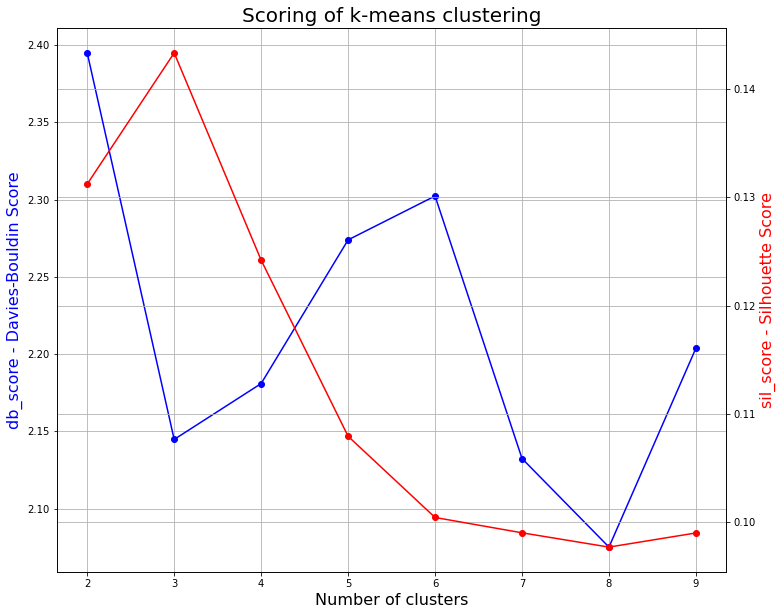

In [23]:
# Create Plot

fig, ax1 = plt.subplots(figsize=(12,10))
plt.title('Scoring of k-means clustering',fontsize=20)
plt.grid()

# First plot
ax1.set_xlabel('Number of clusters',fontsize=16) 
ax1.set_ylabel('db_score - Davies-Bouldin Score',color='blue',fontsize=16) 
ax1.plot(range(2, nb_clust_max), db_score,color = 'blue',marker='o') 

# Second plot

ax2 = ax1.twinx() 
ax2.set_ylabel('sil_score - Silhouette Score',color='red',fontsize=16) 
ax2.plot(range(2, nb_clust_max), sil_score,color = 'red',marker='o') 

# Show plot

plt.grid()
plt.show()

In [24]:
db_score

[2.3949676450416133,
 2.1448420479471246,
 2.1809960707780176,
 2.2739748652595804,
 2.302359143963081,
 2.1324774952435925,
 2.0751740445304705,
 2.2039271122036683]

In [25]:
sil_score

[0.13120556341553793,
 0.14330730152985388,
 0.12419119314330589,
 0.1079371598638536,
 0.10044681107238451,
 0.0990308692124612,
 0.09771363144097277,
 0.0990179081952336]

Plus le Davies Bouldin score est bas, mieux le clustering est bon. Ici, le minimum est sur le k-means de 8 clusters (1.91).
Plus le score de silhouette est proche de 1, mieux le clustering est bon. Ici, le maximum est proche de 0.184 pour 2=3 clusters.
De manière générale, les scores de silhouettes ne sont pas très élevés.
Un compris sur ces graphiques serait de choisir 3 ou 4 clusters.

Essayons d'utiliser un Visualizer pour évaluer chaque cluster créer sinon, il serait intéresser de tester une autre méthode de clustering ou peut-être de modifier les variables explicatives.

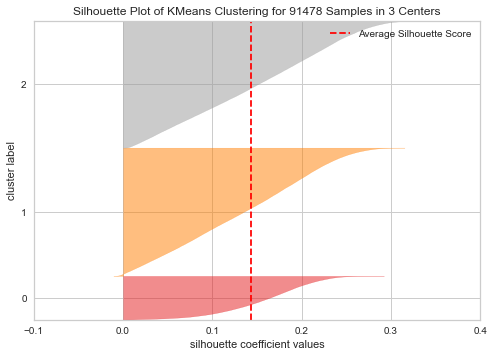

In [26]:
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# Instantiate the clustering model and visualizer 
model = KMeans(3)
visualizer = SilhouetteVisualizer(model)

visualizer.fit(X_trf)    # Fit the data to the visualizer
visualizer.poof()    # Draw/show/poof the data
plt.show()

Le score des silhouettes de chaque cluster n'est effectivment pas très grand.  

## Analyse par composantes principales

Pour pouvoir les visualiser correctement, projetons les individus sur un graphique, en réalisant une ACP en amont:

In [27]:
# Calcul du PCA
n_cpts = 6
pca = decomposition.PCA(n_components=n_cpts).fit(X_trf)
# X_projected = pca.transform(X_trf)

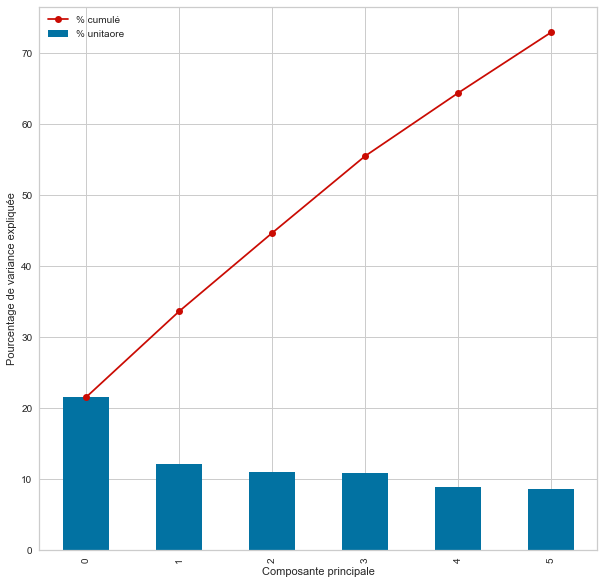

In [28]:
# Visualisation des éboulis des valeurs propres du PCA
pd.DataFrame(pca.explained_variance_ratio_*100).plot.bar(figsize=(10,10))
plt.grid()
plt.plot(range(0, n_cpts),np.cumsum(pca.explained_variance_ratio_*100),marker='o',color='r')
plt.legend(['% cumulé','% unitaore'])
plt.grid()
plt.xlabel('Composante principale')
plt.ylabel('Pourcentage de variance expliquée')
plt.show()

In [29]:
print("Pourcentage de variance expliquée par chacune des composantes: " + str(pca.explained_variance_ratio_))
print("Pourcentage cumulée de variance expliquée pour toute les composantes choisies: " + str(pca.explained_variance_ratio_.sum()))

Pourcentage de variance expliquée par chacune des composantes: [0.21506087 0.12082267 0.11027525 0.10829208 0.08877304 0.08534353]
Pourcentage cumulée de variance expliquée pour toute les composantes choisies: 0.7285674486949378


Il faut au moins 4 composantes principales pour expliquer 50% du comportement des individus, et 6 pour expliquer 80%.

Les deux premières composantes principales permettent d'expliquer plus de 50% du comportement des individus. Les troisième et quatrième composantes expliquent environ 10% chacune, et les autres environ 9% chacune.  
Projetons les variables explicatives sur les plans focaux:

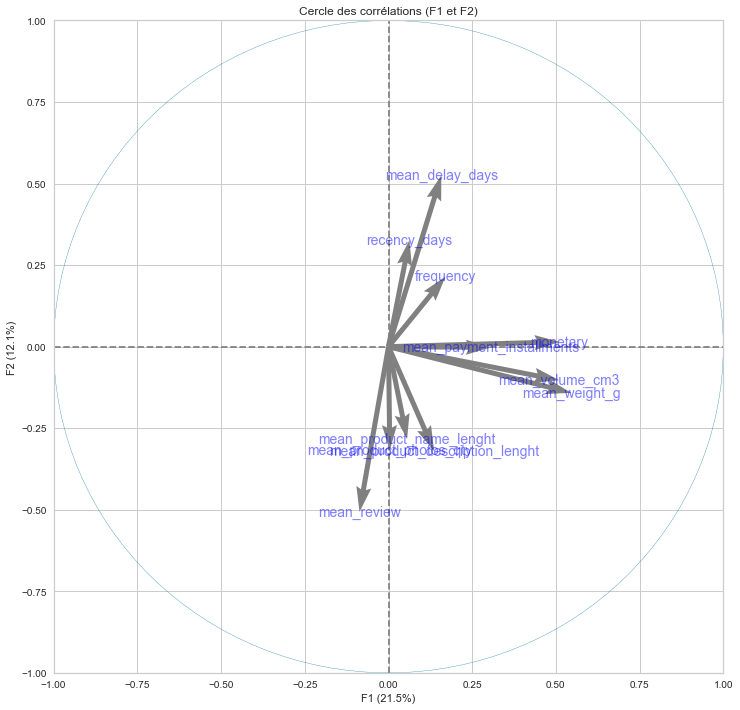

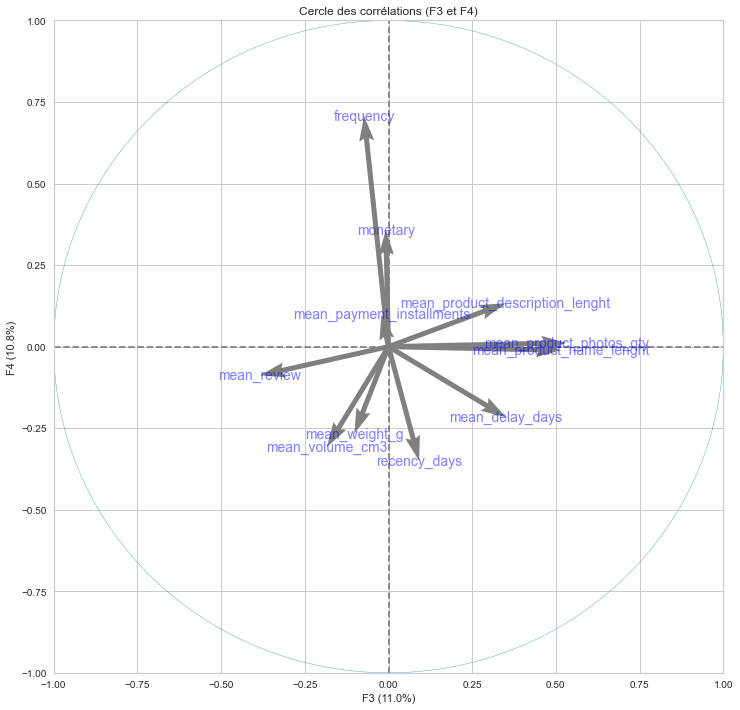

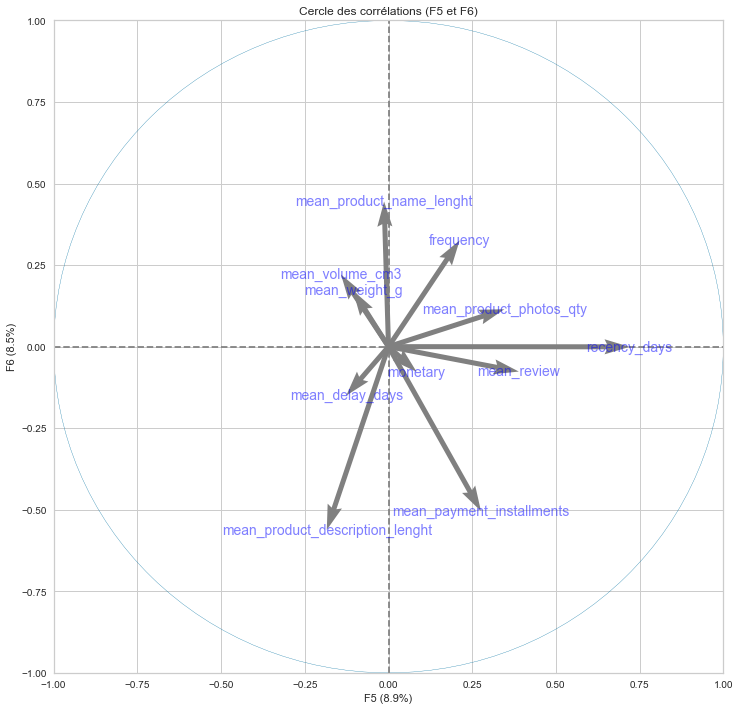

In [30]:
from functions_pca import*
pcs = pca.components_
display_circles(pcs, n_cpts, pca, [(0,1),(2,3),(4,5)], labels = np.array(data_rfm_client.columns),fs=(12,12))

La lecture des variables n'est pas évidente, mais on constate quand même que les variables sont regroupées naturellement sur certaines catégories: catégories monétaires, catégories de dimension, catégories de description du produit commandé, ...  

Sur les premiers axes principaux, le masse et la dimension des articles commandés semblent autant corrélés à l'axe F1 que la valeur monétiare utilisée. Cela indique d'une part qu'un article est d'autant cher qu'il possède de matières. Cependant, lorsqu'un client commande, il n'utilise pas réellement ces informations de quantités de matières. L'utilisation de ces variables risquent d'impacter notre clustering car n'est pas représentatif du comportmeent d'un client.

De même, l'axe F2 est très corrélées à la description d'un article. Moins sa desciption est précise et moins le score sur ce produit est bon.

De ce fait, on décide de réduire le nombre de variables du dataset clients (data_rfm_clients) et de continuer l'étude avec des variables plus impactantes sur le comportement du client.

# Réduction du dataset
On choisit de tester notre clusterisation sur un dataset avec moins de features qui pourraient impacter négativement la clusterisation.  
Notamment, on décide de réduire le nmobre de variable descriptives qui ne sont pas liées au comportement du client et à sa satisfaction finale.

In [31]:
data_rfm_client.shape

(91478, 11)

In [32]:
data_rfm_client_red = data_rfm_client.drop(['mean_volume_cm3','mean_weight_g','mean_product_name_lenght','mean_product_description_lenght'],axis=1)
data_rfm_client_red

,monetary,frequency,recency_days,mean_payment_installments,mean_review,mean_product_photos_qty,mean_delay_days
customer_unique_id,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,141.90,1,1548,8.0,5.0,1.0,6.0
0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,1,1551,1.0,4.0,1.0,3.0
0000f46a3911fa3c0805444483337064,86.22,1,1973,8.0,3.0,3.0,25.0
0000f6ccb0745a6a4b88665a16c9f078,43.62,1,1757,4.0,4.0,5.0,20.0
0004aac84e0df4da2b147fca70cf8255,196.89,1,1724,6.0,5.0,3.0,13.0
...,...,...,...,...,...,...,...
fffcf5a5ff07b0908bd4e2dbc735a684,4134.84,2,1883,10.0,5.0,1.0,27.0
fffea47cd6d3cc0a88bd621562a9d061,84.58,1,1698,1.0,4.0,2.0,30.0
ffff371b4d645b6ecea244b27531430a,112.46,1,2005,1.0,5.0,5.0,14.0


In [33]:
X_values = data_rfm_client_red.values

In [34]:
# Transformation log sur des entrées positives
from sklearn.preprocessing import PowerTransformer
pt_trf = PowerTransformer(method="box-cox")
X_boxcow = pt_trf.fit_transform(1+X_values)

In [35]:
X_trf=X_boxcow

### Inerties intraclasse

In [36]:
# from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import silhouette_score

wcss = []
db_score = []
sil_score = []
nb_clust_max = 10 # len(column_data_num_cut)

for i in range(2, nb_clust_max): # 2 car davies_bouldin_score seulement si nb_cluster >1
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42) 
    kmeans.fit(X_trf) 
    wcss.append(kmeans.inertia_)
    db_score.append(davies_bouldin_score(X_trf, kmeans.labels_))
    sil_score.append(silhouette_score(X_trf, kmeans.labels_))
    print("Calculation done for the following number of clusters: " + str(i))

Calculation done for the following number of clusters: 2
Calculation done for the following number of clusters: 3
Calculation done for the following number of clusters: 4
Calculation done for the following number of clusters: 5
Calculation done for the following number of clusters: 6
Calculation done for the following number of clusters: 7
Calculation done for the following number of clusters: 8
Calculation done for the following number of clusters: 9


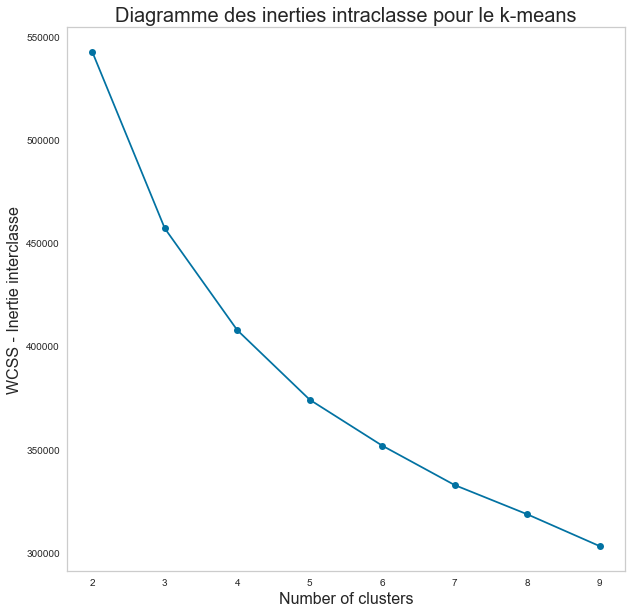

In [37]:
# Tracer des inerties
fig = plt.figure(figsize=(10,10))
plt.plot(range(2, nb_clust_max), wcss,marker='o') 
plt.title('Diagramme des inerties intraclasse pour le k-means',fontsize=20)
# plt.grid()
plt.xlabel('Number of clusters',fontsize=16) 
plt.ylabel('WCSS - Inertie interclasse',fontsize=16) 
plt.grid()
plt.show()

La méthode du coude nous permet d'estimer le nombre de clusters idéals aux alentours de 4.  Cependant, on pourrait utiliser différentes métriques pour s'assurer de la pertinence de ce nombre de cluters, comme le Davies-Score ou le SilhouetteVisualizer:  
### Davies- score et SilhouetteVisualizer

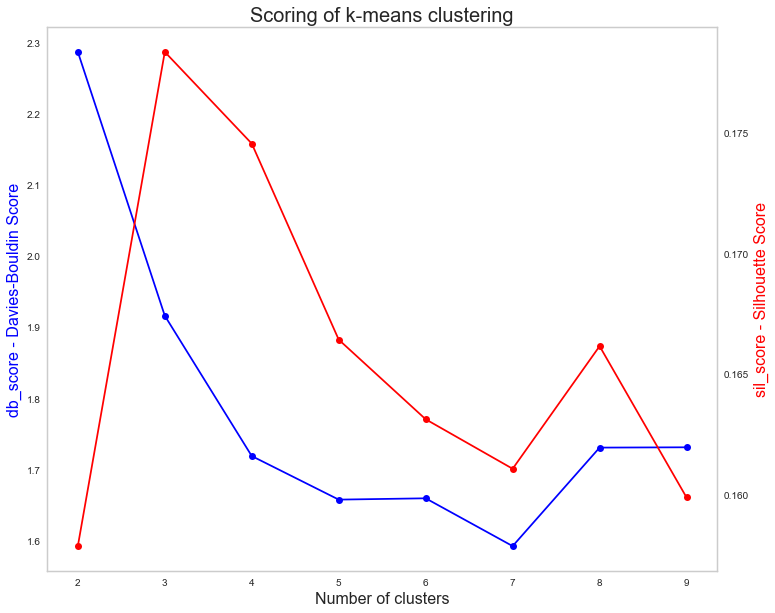

In [38]:
# Create Plot

fig, ax1 = plt.subplots(figsize=(12,10))
plt.title('Scoring of k-means clustering',fontsize=20)
plt.grid()

# First plot
ax1.set_xlabel('Number of clusters',fontsize=16) 
ax1.set_ylabel('db_score - Davies-Bouldin Score',color='blue',fontsize=16) 
ax1.plot(range(2, nb_clust_max), db_score,color = 'blue',marker='o') 

# Second plot

ax2 = ax1.twinx() 
ax2.set_ylabel('sil_score - Silhouette Score',color='red',fontsize=16) 
ax2.plot(range(2, nb_clust_max), sil_score,color = 'red',marker='o') 

# Show plot

plt.grid()
plt.show()

In [39]:
db_score

[2.286268766895092,
 1.9156674009609027,
 1.7186115824722141,
 1.6574119704417314,
 1.6592548815200103,
 1.592133928807326,
 1.7304758035981496,
 1.7309030930859444]

In [40]:
sil_score

[0.15784054466905603,
 0.17836290501314025,
 0.17455531082888012,
 0.1664133778936261,
 0.1631070596847666,
 0.1610520509995387,
 0.16614382348260615,
 0.15985953113622794]

Ici nos scores ont été réduit pour le Davies Bouldin ( [1.59, 2.28] contre [2.15, 2.40] précedemment) et réhaussés pour la silhouette ( [0.159,0.178] contre [0.09, 0.143] précedemment), ce qui est donc meilleur que précédemmenrt.

Bien que les scores ne soient toujours pas les plus performants, les nombres entre 5, 7 et 8 sont d'intéressants candidats de nombre de clusters selon qu'on priorise le db_score ou le sil_score.

On choisit d'avoir une segmentation affinée, donc on prendra 7 clusters.

Utilisons un Visualizer pour évaluer chaque cluster créer sinon, il serait intéresser de tester une autre méthode de clustering ou peut-être de modifier les variables explicatives.  

### SilhouetteVisualizer

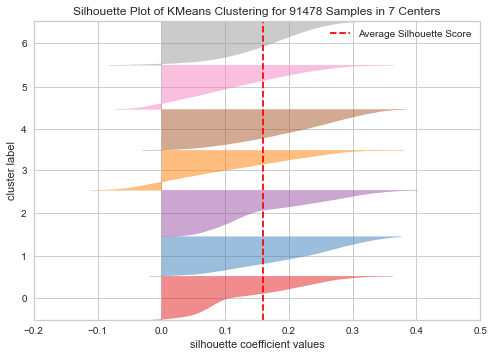

In [41]:
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# Instantiate the clustering model and visualizer 
model = KMeans(7)
visualizer = SilhouetteVisualizer(model)

visualizer.fit(X_trf)    # Fit the data to the visualizer
visualizer.poof()    # Draw/show/poof the data
plt.show()

En moyenne, les scores sont meilleurs qu'avec l'étude précedente. Quelques éléments du cluster n°3  , 5 et 6 semblent mal catégorisés, mais leur proportion ne semble pas très élevée.
Réalisons l'ACP:  

### Analyse par composantes principales

In [42]:
# Calcul du PCA
n_cpts = 6
pca = decomposition.PCA(n_components=n_cpts).fit(X_trf)
# X_projected = pca.transform(X_trf)

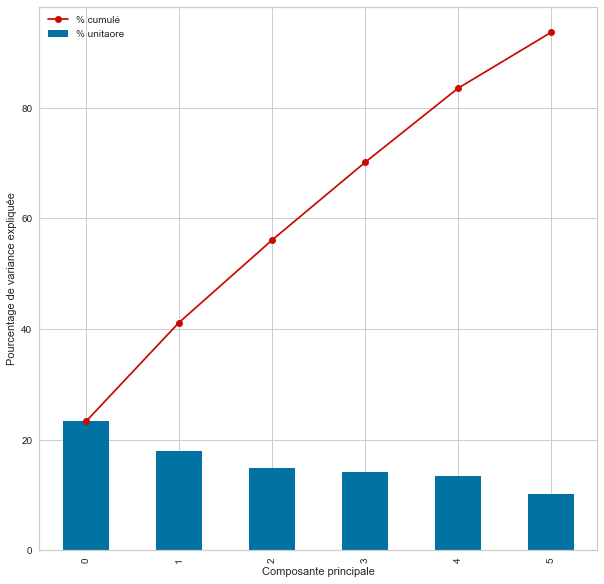

In [43]:
# Visualisation des éboulis des valeurs propres du PCA
pd.DataFrame(pca.explained_variance_ratio_*100).plot.bar(figsize=(10,10))
plt.grid()
plt.plot(range(0, n_cpts),np.cumsum(pca.explained_variance_ratio_*100),marker='o',color='r')
plt.legend(['% cumulé','% unitaore'])
plt.grid()
plt.xlabel('Composante principale')
plt.ylabel('Pourcentage de variance expliquée')
plt.show()

In [44]:
print("Pourcentage de variance expliquée par chacune des composantes: " + str(pca.explained_variance_ratio_))
print("Pourcentage cumulée de variance expliquée pour toute les composantes choisies: " + str(pca.explained_variance_ratio_.sum()))

Pourcentage de variance expliquée par chacune des composantes: [0.23274294 0.1787081  0.14904055 0.14046496 0.13407744 0.10097002]
Pourcentage cumulée de variance expliquée pour toute les composantes choisies: 0.9360040202327355


Il faut au moins 3 composantes principales pour expliquer près de 50% du comportement des individus, et 4 pour expliquer 80%.

Projetons les variables explicatives sur les plans focaux:

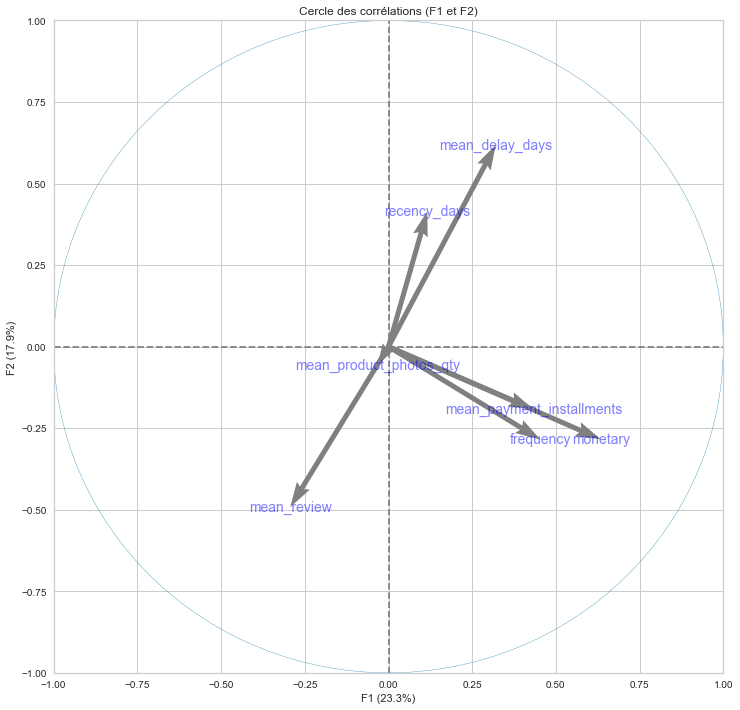

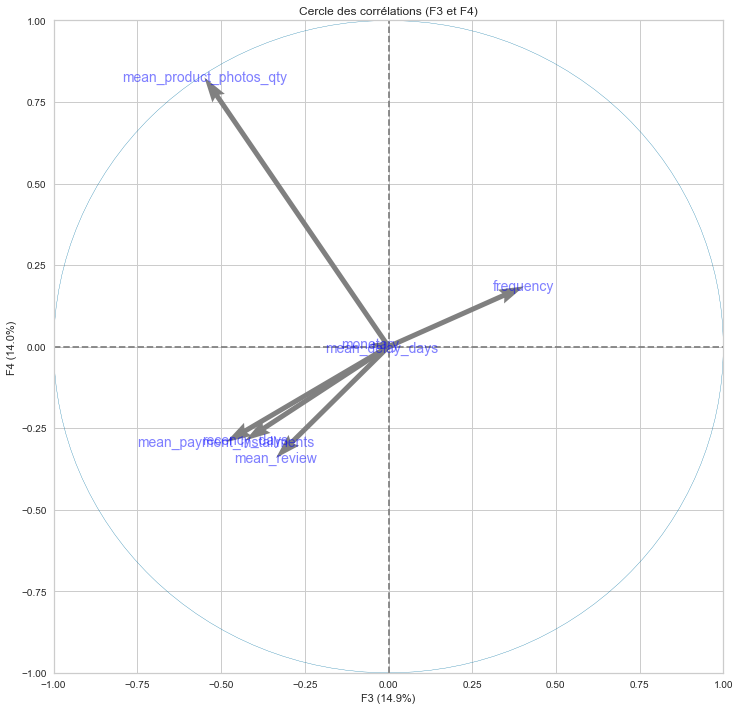

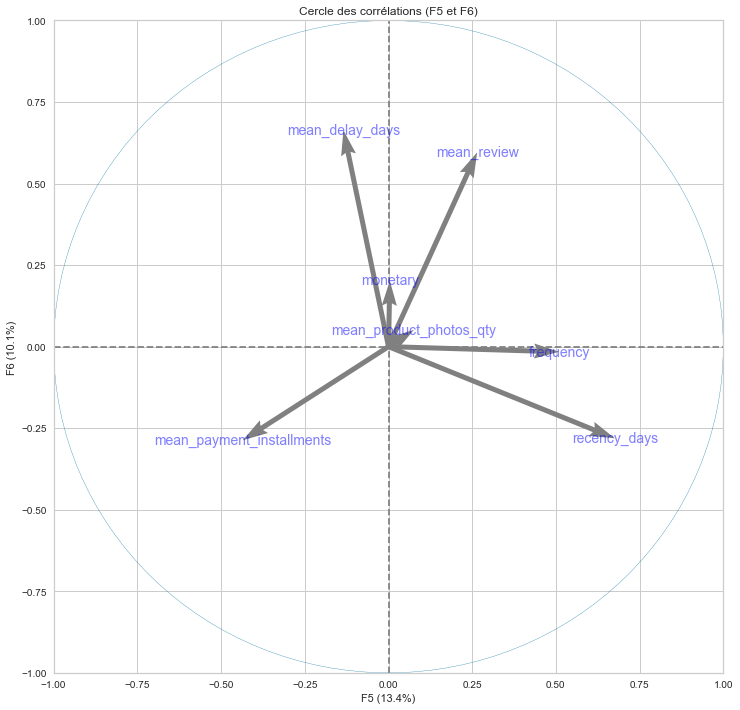

In [45]:
from functions_pca import*
pcs = pca.components_
display_circles(pcs, n_cpts, pca, [(0,1),(2,3),(4,5)], labels = np.array(data_rfm_client_red.columns),fs=(12,12))

La lecture des variables est maintenant plus aisée.  

Sur le 1er plan focal:  
- La fréquecne et la valeur monétaire sont positivement corrélées avec le nombre moyen de transactions réalisées pour effectuer une commande.Ces variables sont plus proches de F1 que de F2.
- On remarque qu'une récence élevée (durée entre la dernière commande et aujourd'hui) semble proche d'un délai de réception d'une commande élevée, et proche de F2.
- L'avis client est négativement corrélée à F1 et F2.

Sur le 2nd plan focal: 
- La quantité de photos est trèscorrélée à F4.
- La reccence et et l'avis client est négativement corrélée à F3 et F4.

Sur le 3ème plan focal: 
- Sur F5, la fréquence et la récence sont positivmeent corrélées à F5.
- On voit que mean_review et mean_delays sont bien positivement corrélées à F6.


Projetons nos individus sur les plans focaux selon les clusters du k-means choisit.  

### Projection des individus sur les axes de l'ACP

In [46]:
X_projected = pca.transform(X_trf)

In [47]:
# Nombre de clusters souhaités

n_clust = 7

# Clustering par K-means
km = KMeans(n_clusters=n_clust, init = 'k-means++', random_state = 42)
km.fit(X_trf)

# Récupération des clusters attribués à chaque individu
clusters = km.labels_

Rendons le graphe plus clair par une autre méthode de visualisation:

In [48]:
cluster_map = pd.DataFrame()
cluster_map['data_index'] = data_rfm_client_red.index.values
cluster_map['cluster'] = km.labels_
cluster_map

,data_index,cluster
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,6
2,0000f46a3911fa3c0805444483337064,3
3,0000f6ccb0745a6a4b88665a16c9f078,0
4,0004aac84e0df4da2b147fca70cf8255,0
...,...,...
91473,fffcf5a5ff07b0908bd4e2dbc735a684,4
91474,fffea47cd6d3cc0a88bd621562a9d061,3
91475,ffff371b4d645b6ecea244b27531430a,2
91476,ffff5962728ec6157033ef9805bacc48,0


In [49]:
df_X_projected = pd.DataFrame(X_projected)
df_X_projected

,0,1,2,3,4,5
0,0.148689,-1.336177,-0.300203,-1.346899,-1.200282,-0.180956
1,-2.226510,-0.088287,1.478153,-0.188632,-0.350687,-1.290660
2,1.296610,2.100521,-1.734329,0.210308,-0.188075,-0.781725
3,-0.005433,1.393269,-1.504280,0.841515,-0.389345,-0.251779
4,0.714681,-0.310763,-1.836213,-0.075907,-0.267916,0.411242
...,...,...,...,...,...,...
91473,3.988613,-0.606799,-0.314114,-1.464217,1.317582,1.109252
91474,-0.076588,1.818536,0.139713,0.596802,0.042775,0.952071
91475,-0.483090,0.923249,-1.585953,0.618651,1.700215,0.650396
91476,0.174482,-0.812405,-1.229337,0.306532,-0.977996,0.542208


In [50]:
df_cluster_pca_red = pd.concat([cluster_map,df_X_projected],axis=1)
df_cluster_pca_red

,data_index,cluster,0,1,2,3,4,5
0,0000366f3b9a7992bf8c76cfdf3221e2,1,0.148689,-1.336177,-0.300203,-1.346899,-1.200282,-0.180956
1,0000b849f77a49e4a4ce2b2a4ca5be3f,6,-2.226510,-0.088287,1.478153,-0.188632,-0.350687,-1.290660
2,0000f46a3911fa3c0805444483337064,3,1.296610,2.100521,-1.734329,0.210308,-0.188075,-0.781725
3,0000f6ccb0745a6a4b88665a16c9f078,0,-0.005433,1.393269,-1.504280,0.841515,-0.389345,-0.251779
4,0004aac84e0df4da2b147fca70cf8255,0,0.714681,-0.310763,-1.836213,-0.075907,-0.267916,0.411242
...,...,...,...,...,...,...,...,...
91473,fffcf5a5ff07b0908bd4e2dbc735a684,4,3.988613,-0.606799,-0.314114,-1.464217,1.317582,1.109252
91474,fffea47cd6d3cc0a88bd621562a9d061,3,-0.076588,1.818536,0.139713,0.596802,0.042775,0.952071
91475,ffff371b4d645b6ecea244b27531430a,2,-0.483090,0.923249,-1.585953,0.618651,1.700215,0.650396
91476,ffff5962728ec6157033ef9805bacc48,0,0.174482,-0.812405,-1.229337,0.306532,-0.977996,0.542208


In [51]:
center_projected = pca.transform(km.cluster_centers_)

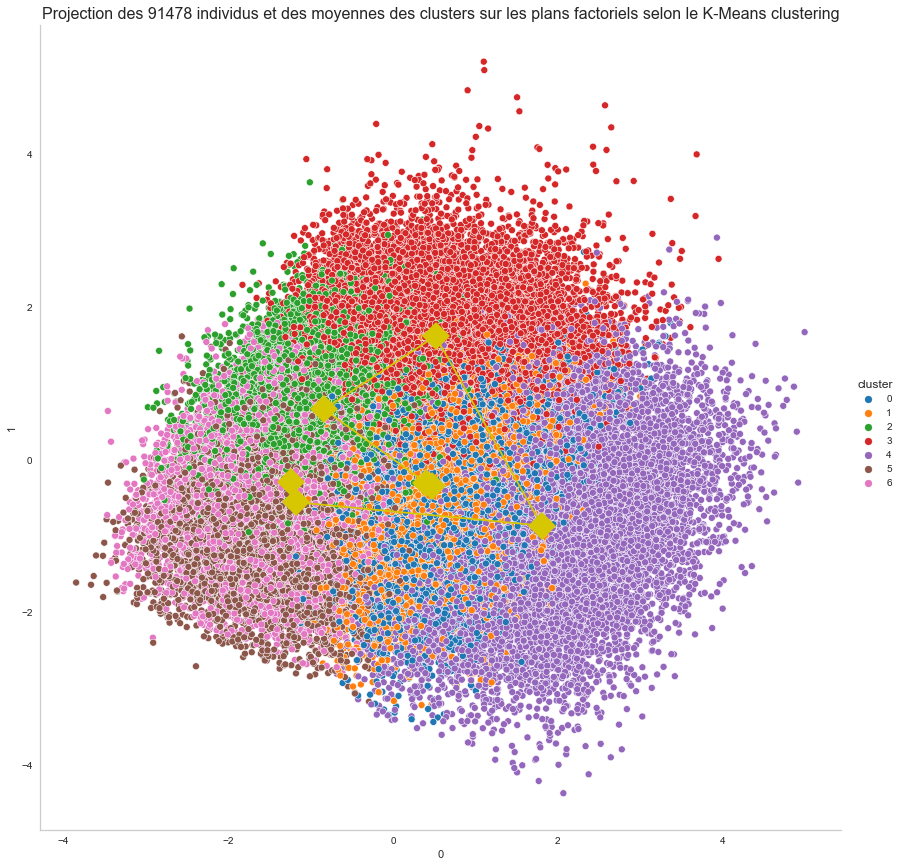

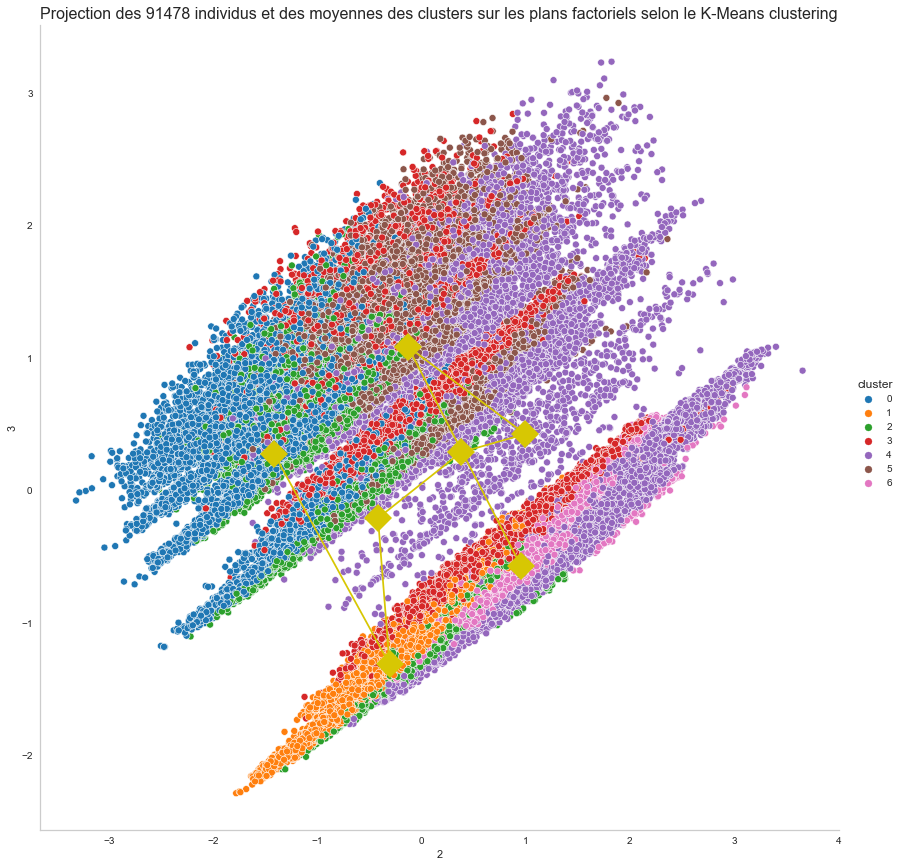

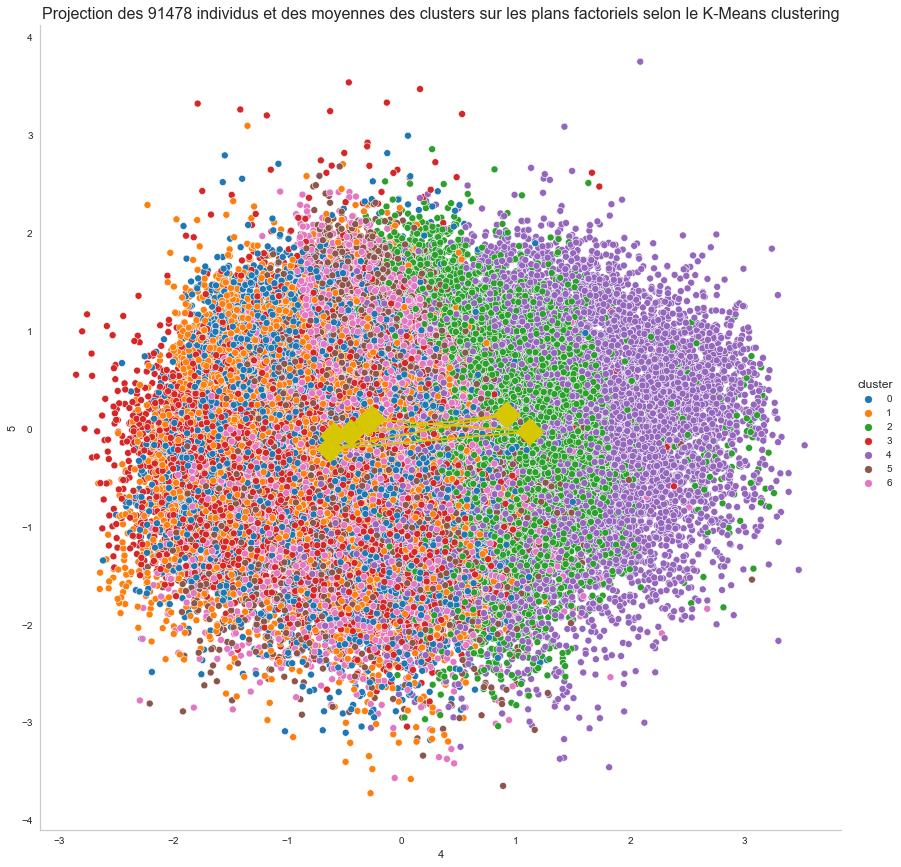

In [52]:
# Si n_cpts pair
for i in range(0,n_cpts,2):
    #print(str(i))
    sns.pairplot(df_cluster_pca_red,x_vars=i,y_vars=i+1,height=12,hue='cluster',palette="tab10") #, plot_kws={'scatter_kws': {'alpha': 0.3}} ) #,alpha=0.2) #, aspect=1.4)
    plt.title('Projection des {} individus et des moyennes des clusters sur les plans factoriels selon le K-Means clustering'.format(X_projected.shape[0]),fontsize=16)
    plt.plot(center_projected[:, i], center_projected[:, i+1], marker = 'D',color='y',ms=20)
#     plt.legend(["Projection des {} individus sur les plans factoriels".format(X_projected.shape[0]),"Projection des moyennes des clusters"])
#     plt.ylim(-15,15)
#     plt.xlim(-15,15)
#     plt.ylim(df_cluster[1].min(),(df_cluster[1].max())
#     plt.xlim((df_cluster[0].min(),(df_cluster[0].max())
    plt.grid()
    plt.show()

- Le cluster 4 en violet semble être celui des clients qui dépensent beaucoup, de manière fréquente et en réalisant des transactions multiples.  
- Le cluster 3 en rouge est celui des clients dont le délai de réception des commande est le plus grand.
- Le cluster 5 en marron est celui des clients qui ont été impactés positivement par la quantités de photos dans la description du produit, et ont relativement bien scorés ces produits.
- Les clusters 0 et 6 (bleu et rose) ont relativement bien scorés les commandes, et en payant en plusieurs transactions. Le cluster 0 est relativement impacté de manière négative sur la quantité de photos.


Pour mieux décire ces résultats, on décide de cartographier par un tableau de contingence proportionnelle et standardisé les variables avec la moyenne des clusters:  

### Cartographies des individus par moyenne des clusters:

In [53]:
# data_rfm_client['cluster']=km.labels_ #cluster_map['cluster'].copy()

In [54]:
df_red = data_rfm_client_red.copy()

In [55]:
df_red = pd.DataFrame(StandardScaler().fit_transform(df_red),columns=data_rfm_client_red.columns.to_list())

In [56]:
# df = ((df-df.mean())/(df.std()))

In [57]:
df_red['cluster']=km.labels_
df_red

,monetary,frequency,recency_days,mean_payment_installments,mean_review,mean_product_photos_qty,mean_delay_days,cluster
0,-0.111533,-0.281339,-0.821883,1.902095,0.660833,-0.723516,-0.640286,1
1,-0.293248,-0.281339,-0.802225,-0.710172,-0.120854,-0.723516,-0.957374,6
2,-0.199737,-0.281339,1.962958,1.902095,-0.902542,0.427988,1.367939,3
3,-0.267221,-0.281339,0.547604,0.409371,-0.120854,1.579492,0.839459,0
4,-0.024422,-0.281339,0.331369,1.155733,0.660833,0.427988,0.099586,0
...,...,...,...,...,...,...,...,...
91473,6.213789,0.903030,1.373227,2.648456,0.660833,-0.723516,1.579331,4
91474,-0.202335,-0.281339,0.161002,-0.710172,-0.120854,-0.147764,1.896420,3
91475,-0.158169,-0.281339,2.172640,-0.710172,0.660833,1.579492,0.205282,2
91476,-0.124538,-0.281339,-0.769462,0.782552,0.660833,0.427988,-0.111806,0


In [58]:
df_red.groupby('cluster').mean()

,monetary,frequency,recency_days,mean_payment_installments,mean_review,mean_product_photos_qty,mean_delay_days
cluster,,,,,,,
0,0.069917,-0.281339,0.127333,0.999205,0.302482,0.796340,-0.071634
1,0.001128,-0.281339,0.042568,0.866054,0.392578,-0.723516,-0.099828
2,-0.179993,-0.270809,1.045487,-0.627588,0.441752,0.015680,-0.036505
3,-0.100908,-0.273437,0.099623,-0.135490,-1.537807,-0.151583,1.178818
4,0.569116,1.597627,0.010143,0.097451,-0.257689,-0.124495,-0.050357
5,-0.177154,-0.270112,-0.788060,-0.559045,0.295677,0.885556,-0.504599
6,-0.197255,-0.271328,-0.706830,-0.612054,0.342828,-0.723516,-0.438571


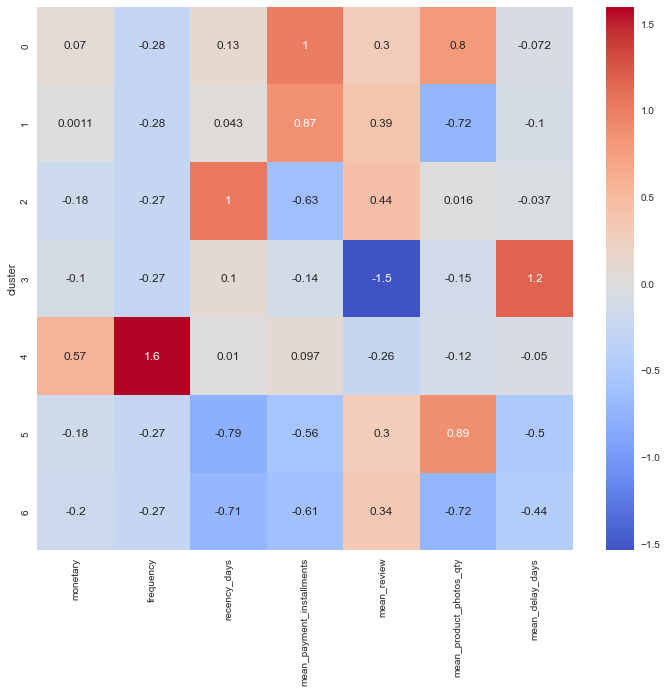

In [59]:
fig, ax = plt.subplots(figsize=(12,10)) 
sns.heatmap(df_red.groupby('cluster').mean(),center=0,cmap='coolwarm',annot=True)
plt.show()

On peut encore une fois statuer du comportement des clients ici:
- Le cluster 4 est celui dont les clients ont le plus commandés et dépensés, et de manière plus récente, mais leur avis sur les produits sont seulement moyens.  

- Le cluster 0 avec le cluster 1 sont ceux les seconds clients qui semblent avoir le plus dépensés en ayant réalisés plusieurs transactions et en ayant donnés des avis très positifs. Le nombre important de photos dans la description du produit a été important pour le cluster 0 mais pas pour le cluster 1. Le cluster 0 a commandé moins récemment que le 1. 

- Les clusters 5 et 6 sont des clients qui paient dans la moyenne, avec peu de transactions et de fréquence, et ayant commandé depuis très longtemps mais donnent des avis relativement bon. Le nombre important de photos dans la description du produit a été important pour le cluster 5 mais pas pour le cluster 6. Le cluster 5 a commandé moins récemment que le 6.  

- Le cluster 3 est celui des clients les plus mécontants. Les avis sont très mauvais et semblent corrélés au temps de livraison des produits qui est le plus grands de tout les clusters.  

- Le cluster 2 corresponds aux clients peu fréquents et les moins récents ayant commandés et donnant des notes relativements bonnes de leur commande. Leur nombre moyen de transactions est le plus bas, peut-être car cette option n'éatit pas encore créée. Ils n'ont pas beaucoup dépensés non plus.


### Diagrammes boîte à moustaches
On peut affirmer tout cela en regardant les diagrammes boîtes à moustache:

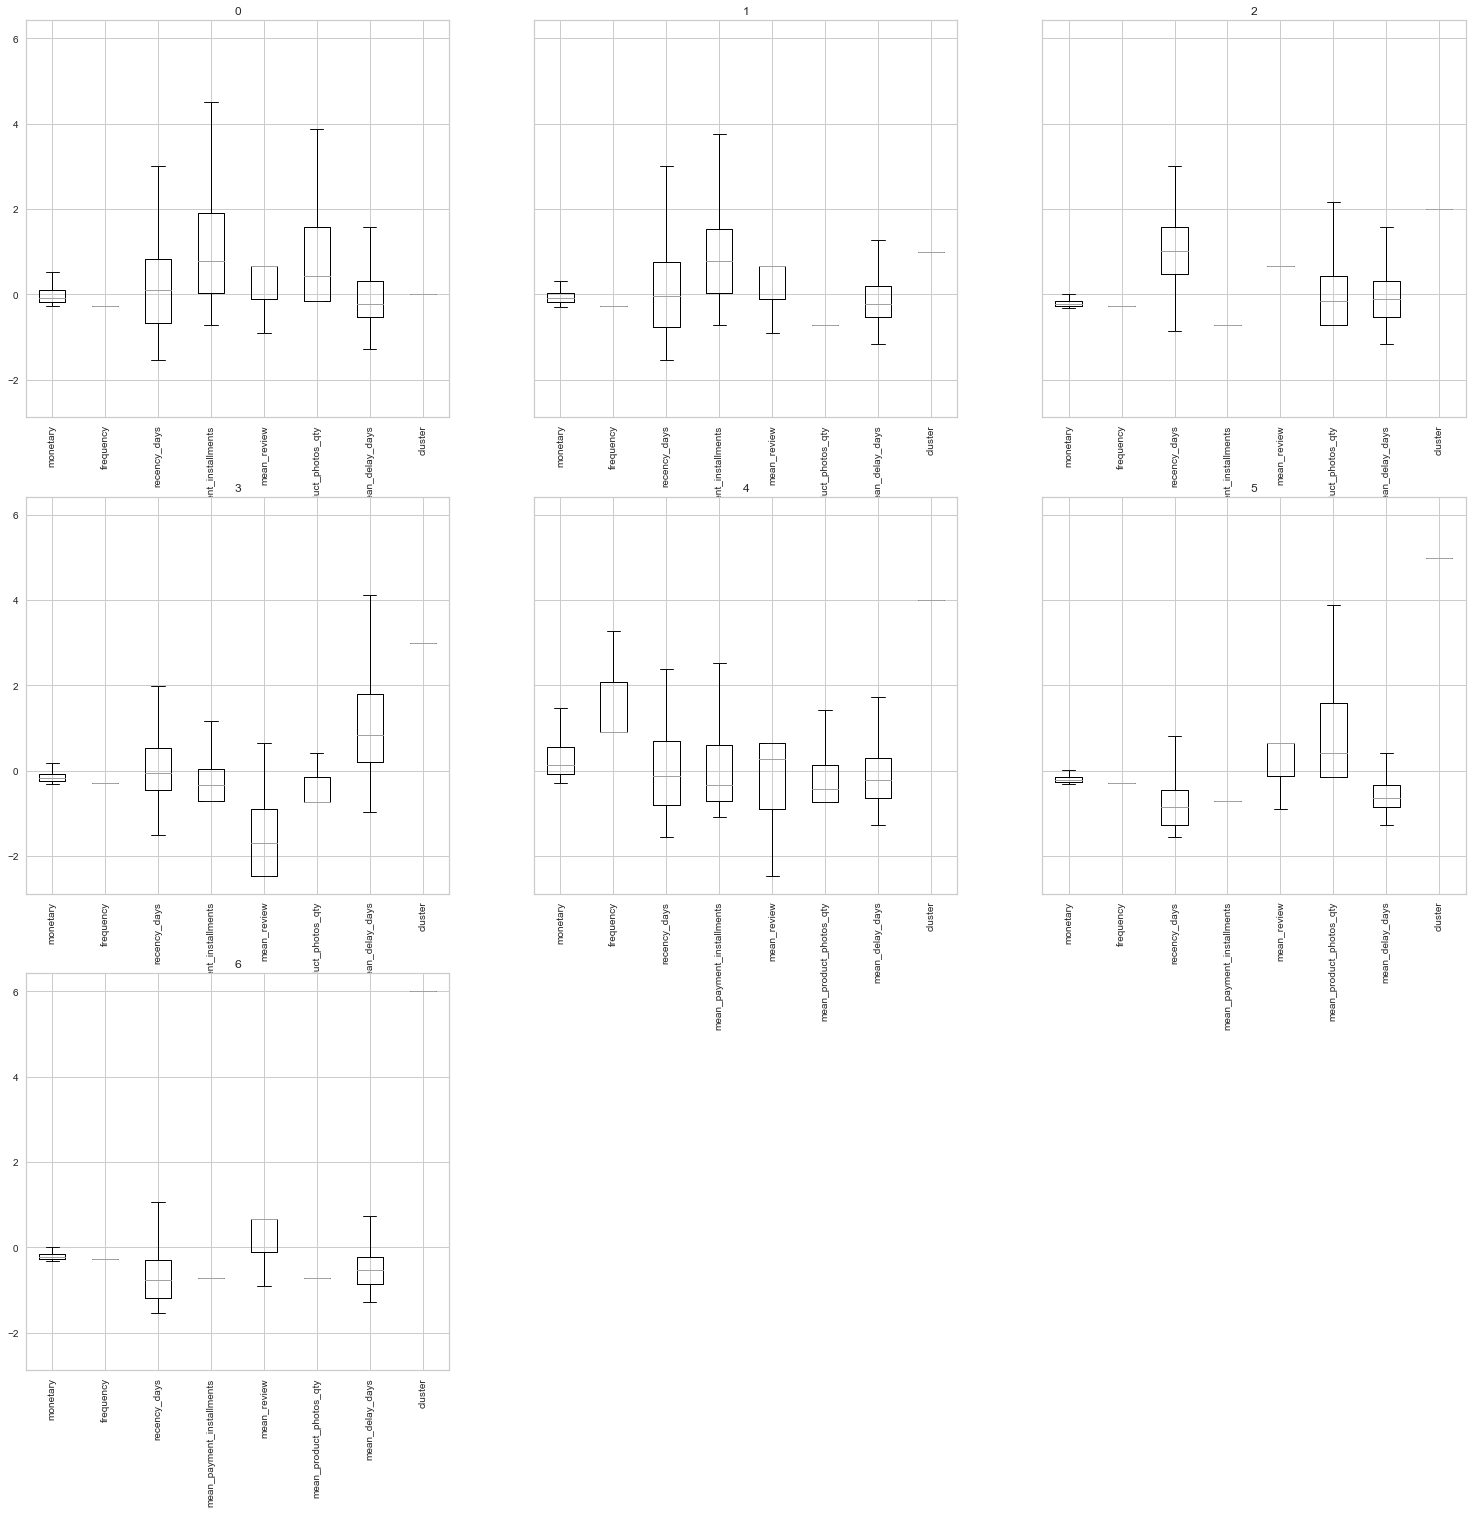

In [60]:
# Etendue des variables par clusters
df_red.groupby('cluster').boxplot(figsize=(25,25),showfliers=False,rot=90)
# plt.title("Etendue des variables par clusters")
plt.show()

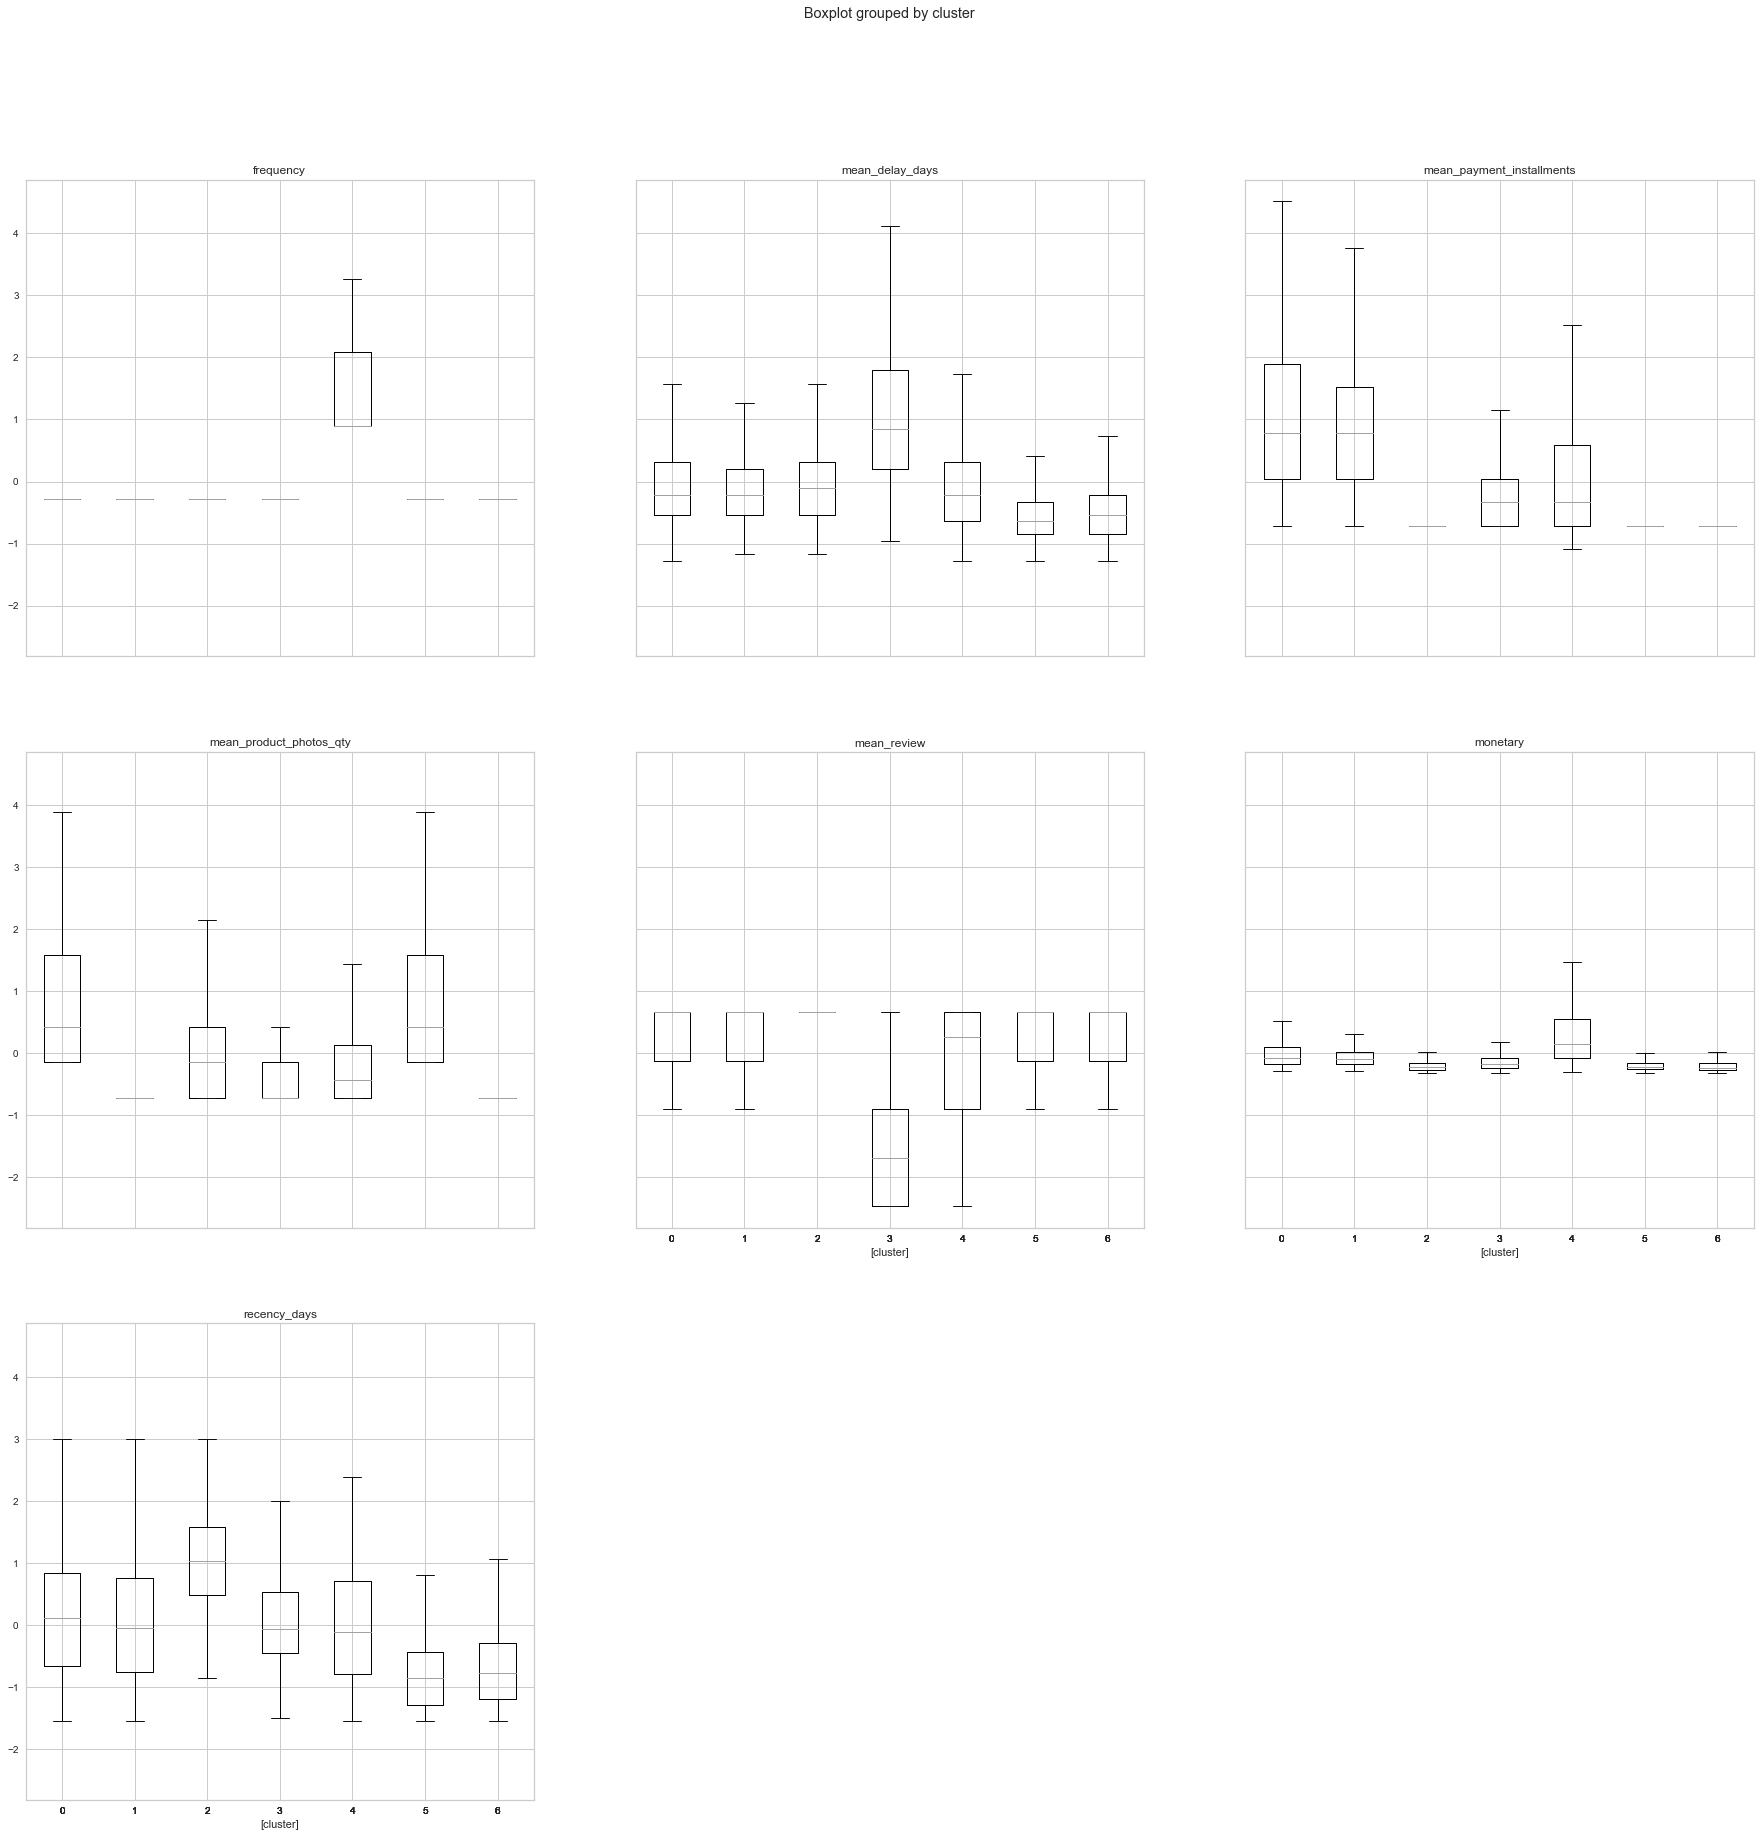

In [61]:
# Etendue des variables par clusters
df_red.boxplot(by='cluster',figsize=(30,30),showfliers=False,rot=0)
plt.show()

#### Etendue des variables par clusters  
- On remarque que le cluster 4 est le seul dont la médiane des fréquences d'achats est à 2. La médiane pour la varibale monetary est elle aussi au-dessus de celles des autres clusters, avec une étendue qui croit. Sur ce cluster, 50% des clients donnent une opinion relativement bonne mais pas nécessairement excellente, et 50% donnent des notes étalées et moins bonnes.
- Le cluster 3 possède au moins 50% de clients avec de mauvaises opinions, 50% relativement mauvaises mais pouvant aussi être bonnes. Les délais de livraisons sont par contre très étendues vers de grandes valeurs.
- Le cluster 2 correspond aux clients les moins récents, donc les plus à avoir commandés, avec une médiane très basse et une étendue des valeurs resserées.  

En ce basant sur toute ces analyses, on peut réaliser prospoections des lcient s différentes d'un groupe à l'autre. Par exemple:
- Solliciter certains groupes avec des mails contenant beaucoup de photos pour certains produits.
- Relancer les anciens clients.
- Proposer des bon d'achat ou des remises à certaines groupes.
- Fidéliser les meilleurs clients avec des cadeaux particuliers.

In [62]:
# data_rfm_client_bis = data_rfm_client.copy()
# data_rfm_client_bis['cluster']=km.labels_

In [63]:
# data_rfm_client_bis.boxplot(by='cluster',figsize=(30,30),showfliers=False,rot=0,column='mean_review')
# plt.show()